In [3]:
import pandas as pd

train_final = pd.read_csv("../data/processed_train.csv")
test_final = pd.read_csv("../data/processed_test.csv")

print("Train shape:", train_final.shape)
print("Test shape:", test_final.shape)
train_final.head()

Train shape: (125973, 123)
Test shape: (22544, 123)


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH,binary_label
0,-0.110249,-0.007679,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,-0.809262,-0.011664,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,normal
1,-0.110249,-0.007737,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,-0.809262,-0.011664,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,normal
2,-0.110249,-0.007762,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,-0.809262,-0.011664,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,attack
3,-0.110249,-0.007723,-0.002891,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,1.235694,-0.011664,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,normal
4,-0.110249,-0.007728,-0.004814,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,1.235694,-0.011664,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,normal


Loading all processed data


In [4]:
X_train = train_final.drop(columns=["binary_label"])
y_train = train_final["binary_label"]

X_test = test_final.drop(columns=["binary_label"])
y_test = test_final["binary_label"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (125973, 122)
y_train shape: (125973,)


Training Logistic Regression 

In [4]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

print("Model trained.")

Model trained.


In [5]:
y_pred = log_reg.predict(X_test)

print(y_pred[:10])

['attack' 'attack' 'normal' 'attack' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal']


.predict(X_test) — feeds all 22,544 test rows through the trained model, and gets back its guess (normal or attack) for each one. Critically, the model has never seen these exact rows during training — this is the real test of whether it learned a genuine pattern.
y_pred[:10] — just peeking at the first 10 predictions, so you can see what the output actually looks like (an array of normal/attack strings, one per row)

In [6]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

      attack       0.92      0.62      0.74     12833
      normal       0.65      0.93      0.76      9711

    accuracy                           0.75     22544
   macro avg       0.78      0.77      0.75     22544
weighted avg       0.80      0.75      0.75     22544



classification_report — a scikit-learn function that calculates precision, recall, and one more metric (F1-score, which we haven't covered yet — I'll explain it once you see it in the output, using your real numbers) for each class separately (attack and normal), plus overall accuracy
y_test — the true, correct answers
y_pred — what your model predicted (from the last cell)
The function compares these two side by side and works out all the TP/TN/FP/FN counts internally, then reports the resulting metrics

In [7]:
cm = confusion_matrix(y_test, y_pred, labels=["normal", "attack"])
print(cm)


[[8993  718]
 [4831 8002]]


confusion_matrix(y_test, y_pred, ...) — compares your true answers against your model's predictions, and tallies up every combination into a small grid
labels=["normal", "attack"] — we're explicitly telling it the order we want the rows/columns in, so the output is predictable and easy to read (rather than whatever alphabetical/internal order it might default to

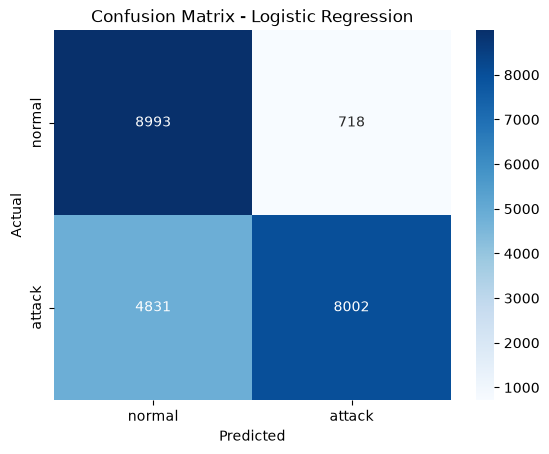

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

os.makedirs("../images", exist_ok=True)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["normal", "attack"], yticklabels=["normal", "attack"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.savefig("../images/confusion_matrix_logreg.png", dpi=150, bbox_inches="tight")
plt.show()

os.makedirs("../images", exist_ok=True) — creates a new images folder at your project root (sibling to data and notebooks) if it doesn't already exist. exist_ok=True just means "don't error if it's already there."
plt.savefig(...) — saves the actual plot image as a PNG file. dpi=150 controls image sharpness, bbox_inches="tight" trims excess whitespace around the plot. This line must come before plt.show(), since plt.show() can clear the plot from memory afterward.

Decission Tree Model

In [9]:
from sklearn.tree import DecisionTreeClassifier

dec_tree = DecisionTreeClassifier(random_state=42)
dec_tree.fit(X_train, y_train)

print("Model trained.")

Model trained.


DecisionTreeClassifier(random_state=42) — creates the model. random_state=42 is worth explaining: Decision Trees have some randomness in how they choose between equally-good splits, so fixing random_state to a specific number makes your results reproducible — if you (or anyone else) reruns this exact code, you'll get the exact same tree, not a slightly different one each time. 42 is just a number people commonly use as a convention (a nod to "Hitchhiker's Guide to the Galaxy," genuinely no deeper meaning) — any fixed number works the same way.
dec_tree — new variable name, distinct from log_reg, so both trained models stay available in memory at once
.fit(X_train, y_train) — same training step as before, same data, different model type

In [10]:
y_pred_tree = dec_tree.predict(X_test)

print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

      attack       0.96      0.65      0.77     12833
      normal       0.68      0.97      0.80      9711

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.84      0.79      0.78     22544



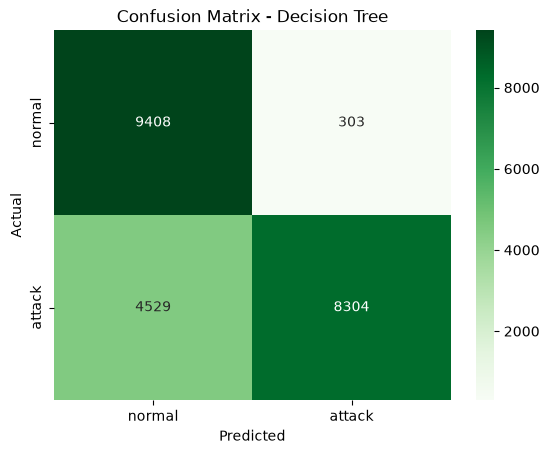

[[9408  303]
 [4529 8304]]


In [11]:
cm_tree = confusion_matrix(y_test, y_pred_tree, labels=["normal", "attack"])

sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Greens", xticklabels=["normal", "attack"], yticklabels=["normal", "attack"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.savefig("../images/confusion_matrix_tree.png", dpi=150, bbox_inches="tight")
plt.show()

print(cm_tree)

Random Forest


In [12]:
from sklearn.ensemble import RandomForestClassifier

rndm_f = RandomForestClassifier(random_state=42)
rndm_f.fit(X_train, y_train)

print("Model trained.") 

Model trained.


RandomForestClassifier(random_state=42) — same random_state reasoning as before, for reproducibility. By default this builds 100 trees (n_estimators=100) — we're using the default for now, but this is a tunable number we could experiment with later
rf — new variable name, so log_reg, dec_tree, and rf all coexist in memory
.fit(X_train, y_train) — same training call as before, same data

In [13]:
y_pred_rndm_f = rndm_f.predict(X_test)

print(classification_report(y_test, y_pred_rndm_f))

              precision    recall  f1-score   support

      attack       0.97      0.61      0.75     12833
      normal       0.65      0.97      0.78      9711

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.77     22544
weighted avg       0.83      0.77      0.76     22544



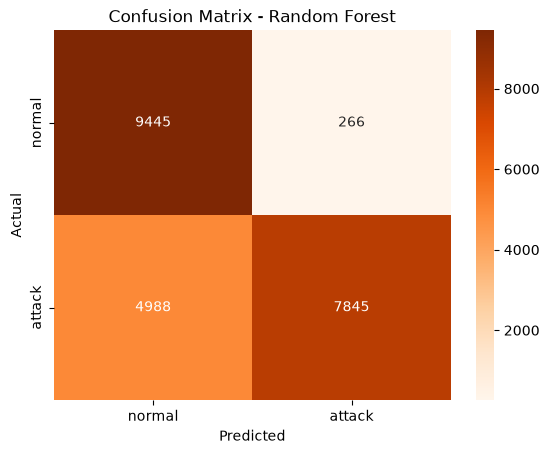

[[9445  266]
 [4988 7845]]


In [14]:
cm_rndm_f = confusion_matrix(y_test, y_pred_rndm_f, labels=["normal", "attack"])

sns.heatmap(cm_rndm_f, annot=True, fmt="d", cmap="Oranges", xticklabels=["normal", "attack"], yticklabels=["normal", "attack"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.savefig("../images/confusion_matrix_rndm_f.png", dpi=150, bbox_inches="tight")
plt.show()

print(cm_rndm_f)

Interpretability : Coefficients Logistics regression 

In [15]:
coefficients = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": log_reg.coef_[0]
})

top_positive = coefficients.sort_values("coefficient", ascending=False).head(10)
top_negative = coefficients.sort_values("coefficient", ascending=True).head(10)

print("Top 10 features pushing toward ATTACK:")
print(top_positive)
print()
print("Top 10 features pushing toward NORMAL:")
print(top_negative)

Top 10 features pushing toward ATTACK:
              feature  coefficient
41        service_IRC    10.022683
12           num_root     6.869388
112          flag_REJ     5.106442
88      service_pop_3     4.732161
101    service_telnet     4.657835
95       service_smtp     4.291544
117           flag_S1     4.229616
53   service_domain_u     3.513697
106     service_urp_i     3.451174
52     service_domain     2.739588

Top 10 features pushing toward NORMAL:
             feature  coefficient
9    num_compromised    -6.735201
116          flag_S0    -3.890180
90   service_private    -3.239079
115        flag_RSTR    -3.198948
62    service_gopher    -2.750413
22   srv_serror_rate    -2.672507
111         flag_OTH    -2.243407
56     service_ecr_i    -2.158903
110    service_whois    -2.048792
2          dst_bytes    -2.014981


In [16]:
train_final["flag_S0"].value_counts()

flag_S0
0.0    91122
1.0    34851
Name: count, dtype: int64

In [17]:
pd.crosstab(train_final["flag_S0"], train_final["binary_label"])

binary_label,attack,normal
flag_S0,,
0.0,24133,66989
1.0,34497,354


In [18]:
train_final["num_compromised"].value_counts().head(10)

num_compromised
-0.011664    124687
 0.030104       976
 0.071872        98
 0.155407        40
 0.113639        38
 0.238943        19
 0.197175        17
 0.280710         5
 0.364246         3
 0.322478         3
Name: count, dtype: int64

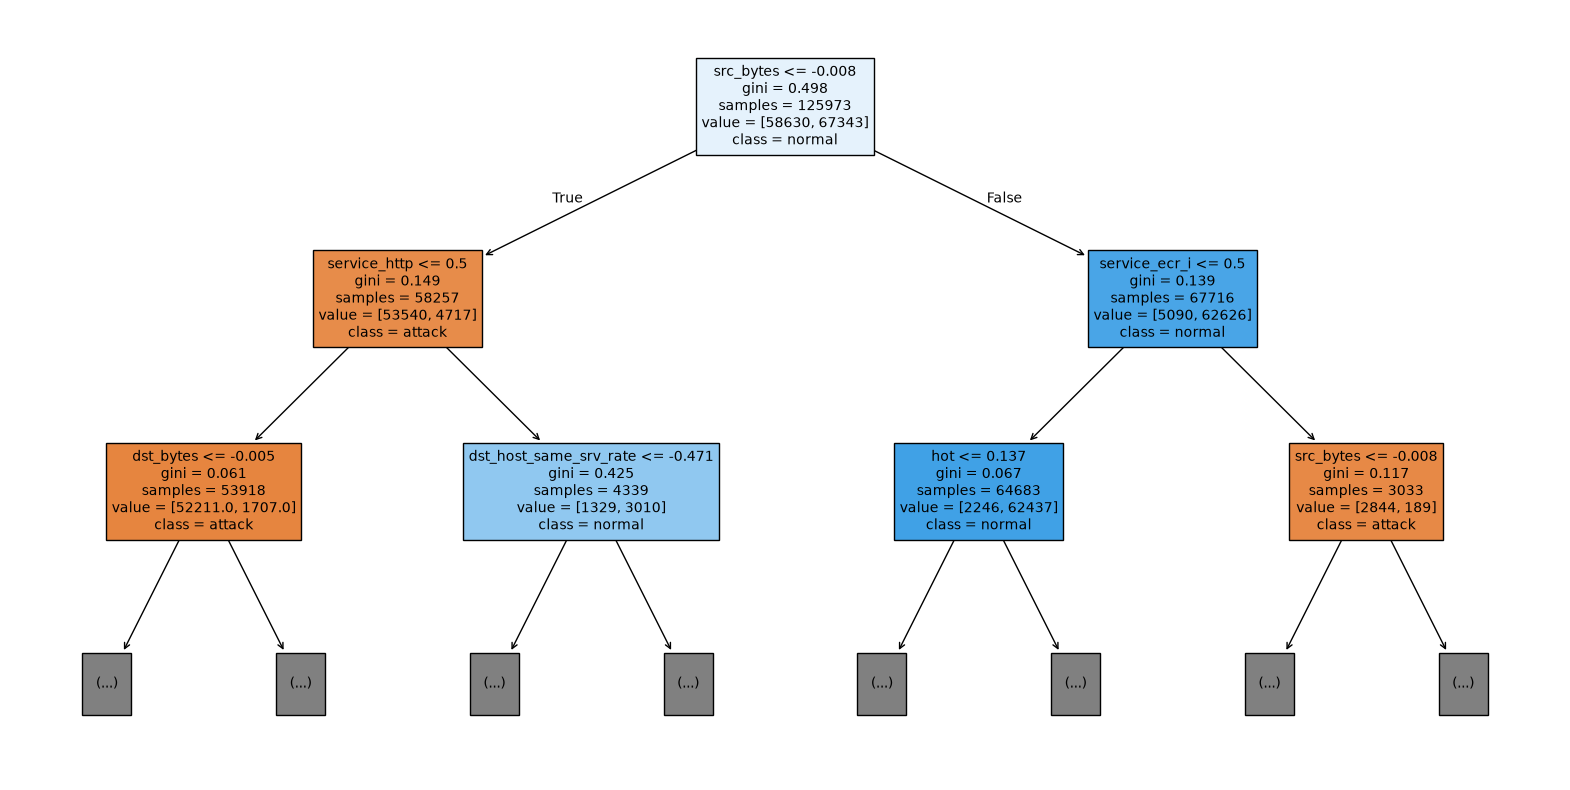

In [19]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(dec_tree, max_depth=2, feature_names=X_train.columns, class_names=dec_tree.classes_, filled=True, fontsize=10)
plt.savefig("../images/decision_tree_viz.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rndm_f.feature_importances_
})

top_features = importances.sort_values("importance", ascending=False).head(15)
print(top_features)

                         feature  importance
1                      src_bytes    0.169311
2                      dst_bytes    0.083189
120                      flag_SF    0.068742
30        dst_host_same_srv_rate    0.057334
29            dst_host_srv_count    0.057008
8                      logged_in    0.052009
25                 same_srv_rate    0.049712
35      dst_host_srv_serror_rate    0.045571
26                 diff_srv_rate    0.039989
38            protocol_type_icmp    0.030113
32   dst_host_same_src_port_rate    0.029634
31        dst_host_diff_srv_rate    0.026363
19                         count    0.023733
116                      flag_S0    0.023017
65                  service_http    0.021276


rf.feature_importances_ — same pattern as .coef_ for Logistic Regression: every trained scikit-learn model stores what it learned as an attribute. For Random Forest, this is the importance score for every feature, in column order
Same DataFrame + sort + head pattern we used for the Logistic Regression coefficients earlier — should feel familiar now

Hyperparameter Tuning (Random Forest)

In [ ]:
from sklearn.model_selection import GridSearchCV 
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "class_weight": ["balanced"]
}

In [5]:
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best parameters: {'class_weight': 'balanced', 'max_depth': None, 'n_estimators': 200}
Best cross-validation score: 0.9989521576113711


In [7]:
from sklearn.metrics import classification_report

best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_best_rf))

              precision    recall  f1-score   support

      attack       0.97      0.63      0.76     12833
      normal       0.67      0.97      0.79      9711

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.78     22544

